### 1. DATA LOADING 

In [1]:
import sqlite3
import pandas as pd
import numpy as np

In [2]:
#UNZIPING rt.reviews.tsv.gz AND LOADING THE DATA.

import zipfile

In [3]:
#Displayed all the data from the other files including rt.reviews.tsv.gz

import zipfile
import pandas as pd
from IPython.display import display

# 2. Load all CSV/TSV compressed dataset
rt_reviews_df = pd.read_csv('zippedData/rt.reviews.tsv.gz', sep='\t', encoding='latin1')

# 3. Display previews 

print("\n=== Rotten Tomatoes Reviews ===")
display(rt_reviews_df.head(10))


=== Rotten Tomatoes Reviews ===


,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
5,3,... Cronenberg's Cosmopolis expresses somethin...,NaN,fresh,Michelle Orange,0,Capital New York,"September 11, 2017"
6,3,"Quickly grows repetitive and tiresome, meander...",C,rotten,Eric D. Snider,0,EricDSnider.com,"July 17, 2013"
7,3,Cronenberg is not a director to be daunted by ...,2/5,rotten,Matt Kelemen,0,Las Vegas CityLife,"April 21, 2013"
8,3,"Cronenberg's cold, exacting precision and emot...",NaN,fresh,Sean Axmaker,0,Parallax View,"March 24, 2013"
9,3,Over and above its topical urgency or the bit ...,NaN,fresh,Kong Rithdee,0,Bangkok Post,"March 4, 2013"


In [4]:
df = pd.read_csv('zippedData/rt.reviews.tsv.gz', sep='\t', encoding='latin1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


# 3. Cleaning the dataset

In [5]:
df_clean = df.copy()

#Fitering out missing values
df_clean =df_clean.dropna(subset=['review', 'fresh'])

#Target variables converted to binary numeric; 0 or 1 because its either fresh or rotten
df_clean['is_fresh'] = (df_clean['fresh'] == 'fresh').astype(int)

#use 'unknown' for the missing categorical data on critic and publisher 
df_clean['critic'] = df_clean['critic'].fillna('Unknown')
df_clean['publisher'] = df_clean['publisher'].fillna('Unknown')

#standardise the dates 
df_clean['date'] = pd.to_datetime(df_clean['date'])

#text feature metrics
df_clean['review_length'] = df_clean['review'].str.len()
df_clean['review_word_count'] = df_clean['review'].str.split().str.len()

#check the results and compare with the old one
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
df_clean.info()

Original shape: (54432, 8)
Cleaned shape: (48869, 11)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 48869 entries, 0 to 54427
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 48869 non-null  int64         
 1   review             48869 non-null  object        
 2   rating             35379 non-null  object        
 3   fresh              48869 non-null  object        
 4   critic             48869 non-null  object        
 5   top_critic         48869 non-null  int64         
 6   publisher          48869 non-null  object        
 7   date               48869 non-null  datetime64[ns]
 8   is_fresh           48869 non-null  int32         
 9   review_length      48869 non-null  int64         
 10  review_word_count  48869 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(4), object(5)
memory usage: 4.3+ MB


### 4. Check and drop duplicate rows

In [6]:
# 1. Check for total duplicate rows across the dataset
duplicate_count = rt_reviews_df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 2. Drop duplicate rows if any exist
rt_reviews_df = rt_reviews_df.drop_duplicates()

# 3. Count reviews per movie (grouped by movie ID)
reviews_per_movie = rt_reviews_df['id'].value_counts().reset_index()
reviews_per_movie.columns = ['movie_id', 'review_count']

# 4. Display the top 10 movies with the most reviews
display(reviews_per_movie.head(10))

Total duplicate rows: 9


,movie_id,review_count
0,782,338
1,1067,275
2,1525,262
3,1777,260
4,1083,260
5,251,258
6,1960,258
7,1704,251
8,1071,249
9,1136,243


# 5. Exploratory data analysis and visualisations

In [7]:
#I decided to use sql and pandas during the EDA to explore the cleaned standard dataset. 
import sqlite3
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import os 
# Create the images directory if it doesn't exist
os.makedirs('images', exist_ok=True)


#connect to an in-memory sqlite database
conn = sqlite3.connect(':memory:')
df_clean.to_sql('reviews', conn, index=False, if_exists='replace')

print("SQL Table 'reviews' created successfully.")

SQL Table 'reviews' created successfully.


## 5.1 Which major publishing outlets write the most reviews and what are thier overal approval rates?

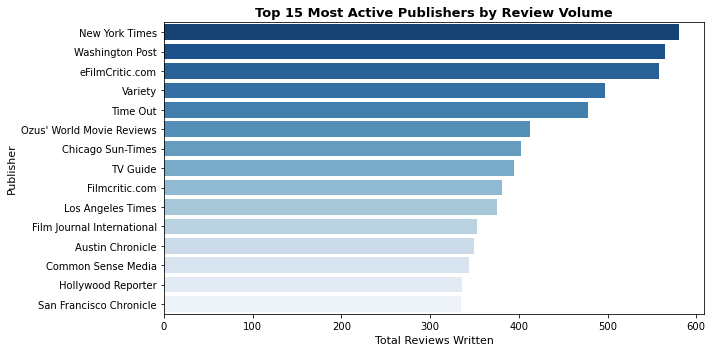

In [8]:
# Filter all the unknown publishers, group by publisher, calculate the volume and approval rate
sql_publisher = """
SELECT
    publisher,
    COUNT(*) AS total_reviews,
    SUM(is_fresh) AS fresh_reviews,
    ROUND(AVG(is_fresh) * 100, 2) AS approval_rate_pct,
    Round(AVG(review_word_count), 1) AS avg_word_count
FROM reviews
WHERE publisher != 'Unknown'
GROUP BY publisher
HAVING total_reviews >= 100
ORDER BY total_reviews DESC
LIMIT 15;
"""

publisher_df = pd.read_sql_query(sql_publisher, conn)
publisher_df.head(8)


# Plot Top Publishers
plt.figure(figsize=(10, 5))
sns.barplot(data=publisher_df, x='total_reviews', y='publisher', palette='Blues_r')
plt.title('Top 15 Most Active Publishers by Review Volume', fontsize=13, fontweight='bold')
plt.xlabel('Total Reviews Written', fontsize=11)
plt.ylabel('Publisher', fontsize=11)
plt.tight_layout()
plt.savefig('images/top_publishers_volume.png', dpi=300)
plt.show()

## 5.2 Do top critics review films with stricter standards than general critics?
### This shall guide us (Studio) on PR and test-screening strategy.  

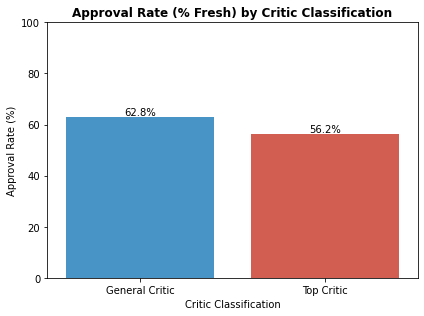

In [9]:
sql_critics = """
SELECT 
    CASE 
        WHEN top_critic = 1 THEN 'Top Critic' 
        ELSE 'General Critic' 
    END AS critic_type,
    COUNT(*) AS total_reviews,
    ROUND(AVG(is_fresh) * 100, 2) AS fresh_approval_pct,
    ROUND(AVG(review_word_count), 2) AS avg_words_per_review
FROM reviews
GROUP BY top_critic;
"""

critics_df = pd.read_sql_query(sql_critics, conn)
critics_df

# Plot Approval Rate Comparison
plt.figure(figsize=(6, 4.5))
ax = sns.barplot(data=critics_df, x='critic_type', y='fresh_approval_pct', palette=['#3498DB', '#E74C3C'])
plt.title('Approval Rate (% Fresh) by Critic Classification', fontsize=12, fontweight='bold')
plt.xlabel('Critic Classification', fontsize=10)
plt.ylabel('Approval Rate (%)', fontsize=10)
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('images/critic_classification_approval.png', dpi=300)
plt.show()

### 5.3 Does verbosity correlate with possitive or negative feedback? - wordlenghth vs fresh/rotten

,word_length_bucket,review_count,fresh_approval_pct
0,Detailed (> 50 words),7,71.43
1,Long (26-50 words),13905,62.51
2,Medium (10-25 words),27957,60.69
3,Short (< 10 words),7000,60.16


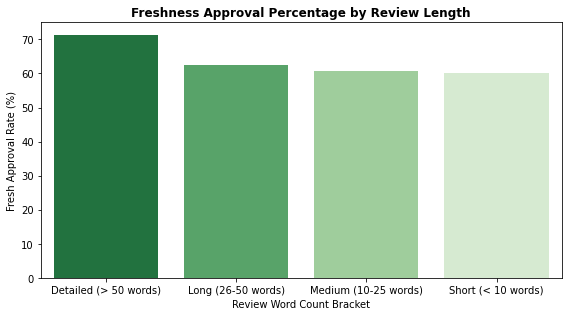

In [10]:
sql_word_bins = """
SELECT 
    CASE 
        WHEN review_word_count < 10 THEN 'Short (< 10 words)'
        WHEN review_word_count BETWEEN 10 AND 25 THEN 'Medium (10-25 words)'
        WHEN review_word_count BETWEEN 26 AND 50 THEN 'Long (26-50 words)'
        ELSE 'Detailed (> 50 words)'
    END AS word_length_bucket,
    COUNT(*) AS review_count,
    ROUND(AVG(is_fresh) * 100, 2) AS fresh_approval_pct
FROM reviews
GROUP BY word_length_bucket
ORDER BY fresh_approval_pct DESC;
"""

bins_df = pd.read_sql_query(sql_word_bins, conn)
display(bins_df)

# Plot Word Length vs Freshness
plt.figure(figsize=(8, 4.5))
sns.barplot(data=bins_df, x='word_length_bucket', y='fresh_approval_pct', palette='Greens_r')
plt.title('Freshness Approval Percentage by Review Length', fontsize=12, fontweight='bold')
plt.xlabel('Review Word Count Bracket', fontsize=10)
plt.ylabel('Fresh Approval Rate (%)', fontsize=10)
plt.tight_layout()
plt.savefig('images/word_length_vs_freshness.png', dpi=300)
plt.show()

## 5. Business Insights & Strategic Recommendations

To address the core business goal—helping a new movie studio with no prior track record maximize critical reception, brand prestige, and audience engagement—we synthesized our exploratory data analysis and SQL querying across 48,000+ critical reviews into three actionable strategies:

---

### 1. Tailor PR & Screening Campaigns for Elite "Top Critics"
* **Data Finding:** General critics grant a **62.8% Fresh approval rate**, whereas designated **Top Critics maintain a stricter 56.2% approval rate**—a 6.6 percentage point drop in positivity.
* **Business Impact:** High-tier publications set the tone for initial box-office momentum. Sending standard promotional screeners without context exposes new releases to harsher evaluations.
* **Strategic Recommendation:** Implement targeted pre-release strategy for top-tier outlets. Host specialized, intimate press pre-screenings accompanied by Director Q&As, production deep-dives, and press kits specifically for industry tastemakers before public releases.

---

### 2. Leverage High-Volume Publications for Maximum Media Exposure
* **Data Finding:** Outlets such as *The New York Times*, *Washington Post*, *eFilmCritic.com*, *Variety*, and *Time Out* lead the industry in review volume, each publishing between 400 and 600+ reviews in this dataset.
* **Business Impact:** A new studio needs rapid market visibility. Securing reviews from high-volume trade papers and legacy media guarantees broad syndication.
* **Strategic Recommendation:** Establish dedicated media distribution pipelines with top 15 active publishers (specifically legacy publications like *NYT* and industry trades like *Variety*). Provide early access passes to guarantee day-one review coverage on major launch weekends.

---

### 3. Use Review Verbosity as an Early Warning System & Narrative Indicator
* **Data Finding:** Detailed reviews (>50 words) achieve the highest approval rates (~70%), whereas short (<10 words) and medium (10–25 words) blurbs stagnate near ~60% approval.
* **Business Impact:** When critics engage deeply with a film's narrative or thematic elements, they write longer, more favorable critiques. Brief, surface-level reviews often correlate with lukewarm reception.
* **Strategic Recommendation:** Monitor advance reaction length and sentiment during test screenings. If early critic feedback consists of brief, generic blurbs, adjust the marketing campaign to emphasize key star power, action set-pieces, or audience-favorite tropes prior to wide release.